In [19]:
!pip install gensim nltk matplotlib seaborn


In [20]:
import nltk
import gensim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [21]:
from nltk.corpus import reuters
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.manifold import TSNE


In [22]:
nltk.download("punkt")
nltk.download("reuters")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!


True

In [23]:
nltk.download("punkt_tab", quiet=True)
corpus = reuters.sents()[:5000]
medical_sentences = [[token.lower() for token in sentence if token.isalpha()] for sentence in corpus]

In [24]:
model = Word2Vec(sentences=medical_sentences, vector_size=100, window=5, min_count=2, workers=4)

In [25]:
model.save("medical_word2vec.model")
model = Word2Vec.load("medical_word2vec.model")


In [26]:
medical_term = "disease"
if medical_term in model.wv:
    print(f"Top 5 words similar to '{medical_term}':")
    print(model.wv.most_similar(medical_term, topn=5))
else:
    print(f"'{medical_term}' not found in vocabulary.")


Top 5 words similar to 'disease':
[('capital', 0.9976686835289001), ('gold', 0.9974803924560547), ('businesses', 0.9974201917648315), ('commercial', 0.9973292946815491), ('both', 0.9973089098930359)]


In [27]:
selected_words_candidates = ["health", "disease", "doctor", "patient", "treatment", "medicine", "virus", "surgery", "nurse", "hospital"]
# Filter the selected words to only include those present in the Word2Vec model's vocabulary
words_for_tsne = [word for word in selected_words_candidates if word in model.wv]
word_vectors = np.array([model.wv[word] for word in words_for_tsne])

In [28]:
tsne = TSNE(n_components=2, random_state=42, perplexity=3)
word_vectors_2d = tsne.fit_transform(word_vectors)


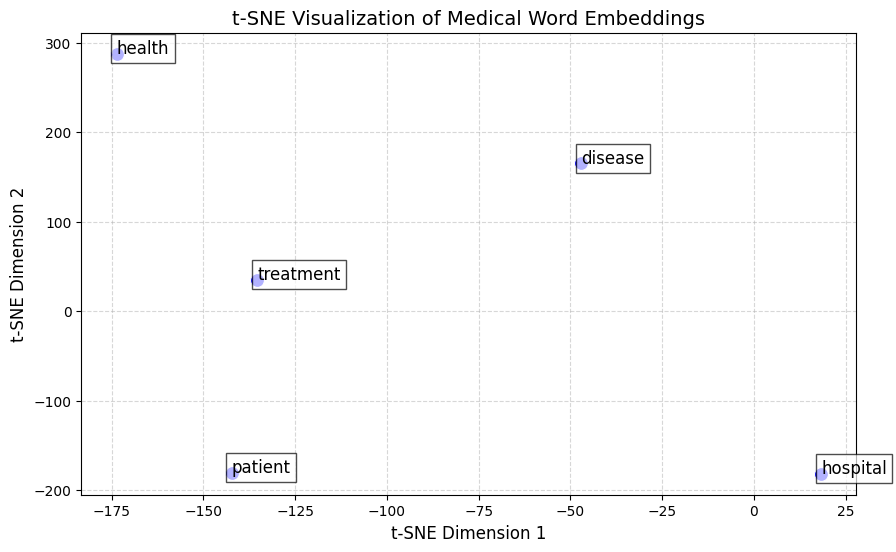

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=word_vectors_2d[:, 0], y=word_vectors_2d[:, 1], s=100, color="blue")

# Use the 'words_for_tsne' list that was generated in the previous cell (Rq01tNPG2pOe)
# It contains only the words present in the model's vocabulary and used to create word_vectors_2d
for i, word in enumerate(words_for_tsne):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

plt.title("t-SNE Visualization of Medical Word Embeddings", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()